In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
rng = np.random.default_rng()

## Betting bankroll simulator

In [67]:
BANKROLL = 100
N_BETS = 1000

P_TRUE = 0.84
ODDS = 1.2

In [68]:
1 / ODDS

0.8333333333333334

In [71]:
def compute_kelly(odds, p_true):

    b = odds - 1
    kelly = (b * p_true - (1 - p_true)) / b
    
    return(kelly)
    

def simulate_bankroll(bankroll = BANKROLL, n_bets = N_BETS, p_true = P_TRUE, odds = ODDS):

    bankroll_states_full_kelly = np.array([bankroll])
    bankroll_states_half_kelly = np.array([bankroll])
    bankroll_states_quarter_kelly = np.array([bankroll])
    
    # p_book = 1 / odds
    # edge = p_true - p_book
    # EV = p_true * odds - 1

    kelly = max(0, compute_kelly(odds, p_true))
    half_kelly = kelly / 2
    quarter_kelly = kelly / 4

    current_bankroll_full_kelly = bankroll
    current_bankroll_half_kelly = bankroll
    current_bankroll_quarter_kelly = bankroll

    for bet in range(n_bets):
        
        win = np.random.binomial(n=1, p=p_true)
        
        if (win == 0):
            current_bankroll_full_kelly = current_bankroll_full_kelly * (1-kelly)
            current_bankroll_half_kelly = current_bankroll_half_kelly * (1-half_kelly)
            current_bankroll_quarter_kelly = current_bankroll_quarter_kelly * (1-quarter_kelly)
        elif (win == 1):
            current_bankroll_full_kelly = current_bankroll_full_kelly * (1 + kelly * (odds - 1))
            current_bankroll_half_kelly = current_bankroll_half_kelly * (1 + half_kelly * (odds - 1))
            current_bankroll_quarter_kelly = current_bankroll_quarter_kelly * (1 + quarter_kelly * (odds - 1))
        else:
            # TODO raise exception
            print("picovina")
            return()


        bankroll_states_full_kelly = np.append(bankroll_states_full_kelly, current_bankroll_full_kelly)
        bankroll_states_half_kelly = np.append(bankroll_states_half_kelly, current_bankroll_half_kelly)
        bankroll_states_quarter_kelly = np.append(bankroll_states_quarter_kelly, current_bankroll_quarter_kelly)
        
    return(bankroll_states_full_kelly, bankroll_states_half_kelly, bankroll_states_quarter_kelly)


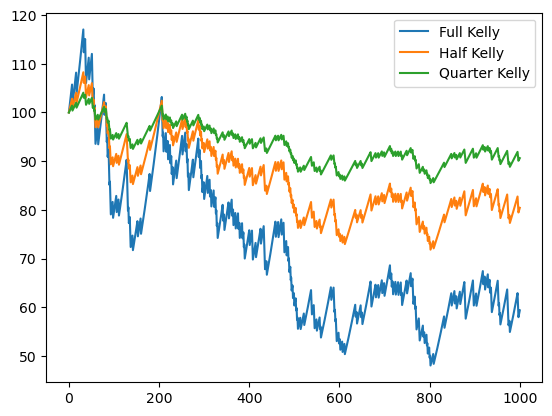

In [72]:
full, half, quarter = simulate_bankroll()

plt.plot(full, label="Full Kelly")
plt.plot(half, label="Half Kelly")
plt.plot(quarter, label="Quarter Kelly")
plt.legend()
plt.show()